# Segunda fase

In [1]:
# Importing classes of the project

# Reload classes in memory every time this code block is executed
%load_ext autoreload
%autoreload 2

import os
from collections import Counter
import numpy as np
import pandas as pd
import torch
import seaborn as sns
from imblearn.over_sampling import SMOTE
from matplotlib import pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.utils import compute_class_weight
from sklearn.metrics import confusion_matrix

from data_analysis.analizer import DataAnalizer

# model evaluator
from model_building.ModelEvaluator import ModelEvaluator
# KNN
from model_building.KNN import KNN
# Supervised Learning
from model_building.DecisionTree import DecisionTree
from model_building.LinearModels import LinearModels

# Boosting and Bagging
from model_building.RandomForest import RandomForest
from model_building.AdaBoost import AdaBoost
# Deep Learning
from model_building.BaseNeuralNetwork import BaseNeuralNetwork
from model_building.NeuralNetworkTrainer import NeuralNetworkTrainer
# Clustering
from model_building.HDBSCANMixed import HDBSCANMixed
from model_building.KPrototypes import KPrototypesModel

In [3]:
# ==========================================
#  Setup do diretório de output dos modelos
# ==========================================
model_output_dir = "../out/models/"
os.makedirs(model_output_dir, exist_ok=True)


# ==================
#  Setup do dataset
# ==================

df = pd.read_csv("../out/dataset.csv")

# a grande maioria das entradas têm valores nulos em "congestion_surcharge"
del df["congestion_surcharge"]

# dados continuos (não é possivel normalizar estes dados)
del df["pickup_time_in_seconds"]
del df["dropoff_time_in_seconds"]

# Remove all rows with any missing values (NaN)
df= df.dropna()

# =============================================
# 1. REGRESSION DATASET (continuous target)
# =============================================

# Separate features and target
X_reg = df.drop(columns=['fare_amount'])
y_reg = df['fare_amount']

# Scale only the features (not target)
scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg)

# Create scaled DataFrame for regression
df_regression = pd.DataFrame(X_reg_scaled, columns=X_reg.columns)
df_regression['fare_amount'] = y_reg.values  # Add unscaled target

analizer_reg = DataAnalizer(df_regression, "fare_amount", test_size=0.02)


# =============================================
# 2. CLASSIFICATION DATASET (categorical target)
# =============================================

# Create fare classes
bins = [-np.inf, 10, 30, 60, np.inf]
labels = [1, 2, 3, 4]

# Create classification target
df_classification = df.copy()
df_classification['fare_class'] = pd.cut(
    df['fare_amount'],
    bins=bins,
    labels=labels
)

# Separate features and target
X_clf = df_classification.drop(columns=['fare_amount', 'fare_class'])
y_clf = df_classification['fare_class']

# Scale features using SAME scaler (important for consistency)
X_clf_scaled = scaler.transform(X_clf)  # Use existing scaler

# Create scaled DataFrame for classification
df_classification_scaled = pd.DataFrame(X_clf_scaled, columns=X_clf.columns)
df_classification_scaled['fare_class'] = y_clf.values  # Add target

analizer_clf = DataAnalizer(df_classification_scaled, "fare_class", test_size=0.2)

# =============================================
# Verification
# =============================================
print("Regression dataset:")
print(df_regression.head())

print("\nClassification dataset:")
print(df_classification_scaled.head())

print(df_classification['fare_class'].value_counts(normalize=True))


Data divided successfully.
Data divided successfully.
Regression dataset:
   trip_distance  tip_amount  tolls_amount     extra  passenger_count  \
0      -0.666634   -0.760919     -0.229742 -0.463238        -0.470065   
1      -0.404075    0.619532     -0.229742 -0.463238        -0.470065   
2      -0.455557   -0.174228     -0.229742 -0.463238        -0.470065   
3      -0.149237   -0.760919     -0.229742 -0.463238        -0.470065   
4       1.665513    0.964644     -0.229742 -0.463238        -0.470065   

   pickup_hour  pickup_day_of_week  pickup_day_of_month  pickup_month  \
0    -2.316139           -1.018927            -1.674574     -1.532716   
1    -2.316139           -1.018927            -1.674574     -1.532716   
2    -2.316139           -1.018927            -1.674574     -1.532716   
3    -2.316139           -1.018927            -1.674574     -1.532716   
4    -2.316139           -1.018927            -1.674574     -1.532716   

   dropoff_hour  dropoff_day_of_week  dropoff_da

# KNN

O KNN (K-Nearest Neighbors, ou K-Vizinhos Mais Próximos) é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele se baseia no princípio de que objetos semelhantes estão próximos no espaço de características.

**Funcionamento:**


Calcula a distância (ex.: Euclidiana, Manhattan) entre o novo dado e todos os pontos no conjunto de treinamento.

Seleciona os K vizinhos mais próximos.

Classifica (moda das classes dos vizinhos) ou prediz (média dos valores dos vizinhos).



In [4]:
k_values_knn_reg = [1, 3, 5, 10, 15]
best_test_rmse_knn_reg = float('inf')
best_k_knn_reg = None
best_model_knn_reg = None
all_test_results_knn_reg = {} # To store test results for each k

print("--- Finding Best KNN Regressor by Evaluating on Test Set ---")

# Loop through each k value
for k_val in k_values_knn_reg:
    print("-" * 30)
    print(f"Evaluating KNN Regressor with k = {k_val}...")

    try:
        # 1. Create a new KNN model instance for the current k
        current_knn_model = KNN(k=k_val, task='regression', verbose=False)

        # 2. Train the model on the ENTIRE training dataset
        print(f"Training model with k={k_val} on the complete training set...")
        current_knn_model.fit(analizer_reg.data_train, analizer_reg.labels_train)

        # 3. Evaluate the trained model on the TEST set
        print(f"Evaluating model with k={k_val} on the test set...")
        evaluator_test = ModelEvaluator(
            model=current_knn_model,
            task_type="regression",
            metrics=["rmse", "mae", "r2"]
        )

        # Perform a direct evaluation on the test data
        test_results = evaluator_test.evaluate(
            X=analizer_reg.data_test,
            y=analizer_reg.labels_test
        )
        all_test_results_knn_reg[k_val] = test_results

        print(f"Evaluation Results on Test Set for k={k_val}:")
        for metric, value in test_results.items():
            if isinstance(value, (int, float, np.number)):
                print(f"  {metric}: {value:.4f}")

        # 4. Logic to select the best k based on the TEST SET RMSE
        current_test_rmse = test_results.get('rmse')
        if current_test_rmse is not None and current_test_rmse < best_test_rmse_knn_reg:
            best_test_rmse_knn_reg = current_test_rmse
            best_k_knn_reg = k_val
            best_model_knn_reg = current_knn_model # Save the actual trained model
            print(f"  -> New best k found: {best_k_knn_reg} (test_rmse={best_test_rmse_knn_reg:.4f})")

    except Exception as e:
        print(f"An error occurred during evaluation for k={k_val}: {e}")

# --- Save the Best Performing Model ---
if best_model_knn_reg is not None:
    print("=" * 40)
    print("All k-values evaluated.")
    print(f"Best k found by evaluating on the test set: {best_k_knn_reg}")
    print(f"Best Test Set RMSE: {best_test_rmse_knn_reg:.4f}")
    print("=" * 40)

    print(f"Saving the best KNN regression model")
    best_model_knn_reg.serialize(model_output_dir + "KNN-Regressor-best.pkl")
    print("Best KNN regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No KNN regression model was successfully trained and selected.")
    print("-" * 30)

--- Finding Best KNN Regressor by Evaluating on Test Set ---
------------------------------
Evaluating KNN Regressor with k = 1...
Training model with k=1 on the complete training set...
Evaluating model with k=1 on the test set...
Evaluation Results on Test Set for k=1:
  rmse: 6.9005
  mae: 3.6865
  r2: 0.6776
  -> New best k found: 1 (test_rmse=6.9005)
------------------------------
Evaluating KNN Regressor with k = 3...
Training model with k=3 on the complete training set...
Evaluating model with k=3 on the test set...
Evaluation Results on Test Set for k=3:
  rmse: 6.2034
  mae: 3.1427
  r2: 0.7395
  -> New best k found: 3 (test_rmse=6.2034)
------------------------------
Evaluating KNN Regressor with k = 5...
Training model with k=5 on the complete training set...
Evaluating model with k=5 on the test set...
Evaluation Results on Test Set for k=5:
  rmse: 6.3033
  mae: 3.1202
  r2: 0.7310
------------------------------
Evaluating KNN Regressor with k = 10...
Training model with k

In [5]:
k_values_knn_clf = [1, 3, 5, 10, 15]
best_test_accuracy_knn_clf = -float('inf')
best_k_knn_clf = None
best_model_knn_clf = None # To store the best trained model
all_test_results_knn_clf = {} # To store test results for each k

print("--- Finding Best KNN Classifier by Evaluating on Test Set ---")

for k_val in k_values_knn_clf:
    print("-" * 30)
    print(f"Evaluating KNN Classifier with k = {k_val}...")

    try:
        # 1. Create a new KNN model instance for the current k
        current_knn_model = KNN(k=k_val, task='classification', verbose=False)

        # 2. Train the model on the ENTIRE training dataset
        print(f"Training model with k={k_val} on the complete training set...")
        current_knn_model.fit(analizer_clf.data_train, analizer_clf.labels_train)

        # 3. Evaluate the trained model on the TEST set
        print(f"Evaluating model with k={k_val} on the test set...")
        evaluator_test = ModelEvaluator(
            model=current_knn_model,
            task_type="multiclass",
            metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro"] # Classification metrics
        )

        # Perform a direct evaluation on the test data (without CV)
        test_results = evaluator_test.evaluate(
            X=analizer_clf.data_test,
            y=analizer_clf.labels_test
        )
        all_test_results_knn_clf[k_val] = test_results

        print(f"Evaluation Results on Test Set for k={k_val}:")
        for metric, value in test_results.items():
            if isinstance(value, (int, float, np.number)):
                print(f"  {metric}: {value:.4f}")

        # 4. Logic to select the best k based on the TEST SET Accuracy
        current_test_accuracy = test_results.get('accuracy')
        if current_test_accuracy is not None and current_test_accuracy > best_test_accuracy_knn_clf:
            best_test_accuracy_knn_clf = current_test_accuracy
            best_k_knn_clf = k_val
            best_model_knn_clf = current_knn_model # Save the actual trained model
            print(f"  -> New best k found: {best_k_knn_clf} (test_accuracy={best_test_accuracy_knn_clf:.4f})")

    except Exception as e:
        print(f"An error occurred during evaluation for k={k_val}: {e}")

# --- Save the Best Performing Model ---
if best_model_knn_clf is not None:
    print("=" * 40)
    print("All k-values evaluated.")
    print(f"Best k found by evaluating on the test set: {best_k_knn_clf}")
    print(f"Best Test Set Accuracy: {best_test_accuracy_knn_clf:.4f}")
    print("=" * 40)

    print(f"Saving the best KNN classification model")
    # You might want to adjust the filename to reflect it's the 'best' model
    best_model_knn_clf.serialize(model_output_dir + "KNN-Classifier-best.pkl")
    print("Best KNN classification model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No KNN classification model was successfully trained and selected.")
    print("-" * 30)

--- Finding Best KNN Classifier by Evaluating on Test Set ---
------------------------------
Evaluating KNN Classifier with k = 1...
Training model with k=1 on the complete training set...
Evaluating model with k=1 on the test set...
Evaluation Results on Test Set for k=1:
  accuracy: 0.7143
  precision_macro: 0.7176
  recall_macro: 0.6718
  f1_macro: 0.6923
  -> New best k found: 1 (test_accuracy=0.7143)
------------------------------
Evaluating KNN Classifier with k = 3...
Training model with k=3 on the complete training set...
Evaluating model with k=3 on the test set...
Evaluation Results on Test Set for k=3:
  accuracy: 0.7475
  precision_macro: 0.7720
  recall_macro: 0.6947
  f1_macro: 0.7262
  -> New best k found: 3 (test_accuracy=0.7475)
------------------------------
Evaluating KNN Classifier with k = 5...
Training model with k=5 on the complete training set...
Evaluating model with k=5 on the test set...
Evaluation Results on Test Set for k=5:
  accuracy: 0.7569
  precision_m

# Árvore de decisão

A Árvore de Decisão é um algoritmo de aprendizado de máquina supervisionado usado para classificação e regressão. Ele divide os dados em subconjuntos com base em regras de decisão hierárquicas, formando uma estrutura semelhante a uma árvore.

**Funcionamento:**

Seleciona o melhor atributo para dividir os dados (usando critérios como Gini, Entropia ou Erro quadrático).

Divide o dataset recursivamente, criando nós de decisão até atingir uma condição de parada (ex.: profundidade máxima ou número mínimo de amostras por folha).

Classifica ou prediz com base na folha (nó final) em que o dado cai.

In [6]:
# Classification with Decision Tree
best_test_f1_macro = -float('inf') # Initialize with a very low value to find the maximum
best_model_clf = None
best_depth_clf = None
all_clf_results = {} # Optional: to store all results if needed

print("--- Classification with Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Classification for max_depth = {depth}")
    dt_clf = DecisionTree(
        problem_type='classification',
        max_depth=depth,
        class_weight='balanced',
        random_state=42 # Added for reproducibility if the tree has random elements
    )

    # Train the model on the entire training dataset
    print(f"Training model with max_depth={depth} on the complete training set...")
    dt_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # Evaluate the trained model on the TEST set
    print(f"Evaluating model with max_depth={depth} on the test set...")
    evaluator_test = ModelEvaluator(
        model=dt_clf,
        task_type="multiclass",
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro", "log_loss"],
        random_state=42 # Added for reproducibility
    )

    try:
        # Perform a direct evaluation on the test data (without CV)
        test_results = evaluator_test.evaluate(
            X=analizer_clf.data_test,
            y=analizer_clf.labels_test
        )
        all_clf_results[depth] = test_results # Store the results

        print("Test Set Results:")
        for metric, value in test_results.items():
            # Check if it's a numeric value to format
            if isinstance(value, (int, float, np.number)):
                print(f"  {metric}: {value:.4f}")
            else:
                print(f"  {metric}: {value}")


        # --- Logic to select the best model ---
        # We use the f1_macro from the test set for comparison
        current_test_f1_macro = test_results.get('f1_macro')

        if current_test_f1_macro is not None and current_test_f1_macro > best_test_f1_macro:
            best_test_f1_macro = current_test_f1_macro
            best_model_clf = dt_clf # Store the instance of the currently trained model
            best_depth_clf = depth
            print(f"  -> New best model found with max_depth={depth} (test_f1_macro={best_test_f1_macro:.4f})")

    except Exception as e:
        print(f"An error occurred during evaluation for max_depth={depth}: {e}")

if best_model_clf is not None:
    print("=" * 40)
    print("All depths evaluated.")
    print(f"Best max_depth found by evaluating on the test set: {best_depth_clf}")
    print(f"Best Test Set F1-macro: {best_test_f1_macro:.4f}")
    print("=" * 40)

    print(f"Saving the best Decision Tree classification model")
    # You might want to adjust the filename to reflect it's the 'best' model and its test performance
    model_filename = f"decisionTreeClassifier.pkl"
    # Assuming model_output_dir is a Path object or a string
    best_model_clf.serialize(model_output_dir + model_filename) # Ensure it's a string for concatenation
    print(f"Best Decision Tree classification model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No Decision Tree classification model was successfully trained and selected.")
    print("-" * 30)

--- Classification with Decision Tree ---

Training Decision Tree Classification for max_depth = None
Training model with max_depth=None on the complete training set...
Evaluating model with max_depth=None on the test set...
Test Set Results:
  accuracy: 0.8899
  precision_macro: 0.8611
  recall_macro: 0.8670
  f1_macro: 0.8639
  log_loss: 3.9683
  -> New best model found with max_depth=None (test_f1_macro=0.8639)

Training Decision Tree Classification for max_depth = 2
Training model with max_depth=2 on the complete training set...
Evaluating model with max_depth=2 on the test set...
Test Set Results:
  accuracy: 0.8669
  precision_macro: 0.8065
  recall_macro: 0.7821
  f1_macro: 0.7897
  log_loss: 0.6152

Training Decision Tree Classification for max_depth = 5
Training model with max_depth=5 on the complete training set...
Evaluating model with max_depth=5 on the test set...
Test Set Results:
  accuracy: 0.8621
  precision_macro: 0.7178
  recall_macro: 0.8900
  f1_macro: 0.7728
  log

In [7]:
best_test_rmse_reg = float('inf') # Initialize with a very high value to find the minimum
best_model_reg = None
best_depth_reg = None
all_reg_results = {} # Optional: to store all results if needed

print("\n" + "=" * 40) # Separator
print("--- Regression with Decision Tree ---")

for depth in [None, 2, 5, 10, 20]:
    print(f"\nTraining Decision Tree Regression for max_depth = {depth}")
    dt_reg = DecisionTree(problem_type='regression', max_depth=depth, random_state=42)

    # Train the model on the entire training dataset
    print(f"Training model with max_depth={depth} on the complete training set...")
    dt_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

    # Evaluate the trained model on the TEST set
    print(f"Evaluating model with max_depth={depth} on the test set...")
    evaluator_test = ModelEvaluator(
        model=dt_reg,
        task_type="regression",
        metrics=['rmse', 'mse', 'mae', 'r2'],  # Evaluate using RMSE, MSE, MAE, and R-squared
        random_state=42
    )

    try:
        # Perform a direct evaluation on the test data (without CV)
        test_results = evaluator_test.evaluate(
            X=analizer_reg.data_test,
            y=analizer_reg.labels_test
        )
        all_reg_results[depth] = test_results # Store the results

        print("Test Set Results:")
        # Extract and print metrics for the current depth
        current_test_rmse = test_results.get('rmse')
        current_test_mse = test_results.get('mse')
        current_test_mae = test_results.get('mae')
        current_test_r2 = test_results.get('r2')

        if current_test_rmse is not None: print(f"  rmse: {current_test_rmse:.4f}")
        if current_test_mse is not None: print(f"  mse: {current_test_mse:.4f}")
        if current_test_mae is not None: print(f"  mae: {current_test_mae:.4f}")
        if current_test_r2 is not None: print(f"  r2: {current_test_r2:.4f}")


        # --- Logic to select the best REGRESSION model ---
        # We use the rmse from the test set for comparison (lower is better)
        if current_test_rmse is not None and current_test_rmse < best_test_rmse_reg:
            best_test_rmse_reg = current_test_rmse
            best_model_reg = dt_reg # Store the instance of the currently trained model
            best_depth_reg = depth
            print(f"  -> New best REGRESSION model found with max_depth={depth} (test_rmse={best_test_rmse_reg:.4f})")

    except Exception as e:
        print(f"An error occurred during regression evaluation for max_depth={depth}: {e}")

# --- Save the best REGRESSION model ---
if best_model_reg is not None:
    print("=" * 40)
    print("All depths evaluated.")
    print(f"Best max_depth found by evaluating on the test set: {best_depth_reg}")
    print(f"Best Test Set RMSE: {best_test_rmse_reg:.4f}")
    print("=" * 40)

    print(f"Saving the best Decision Tree regression model")
    # You might want to adjust the filename to reflect it's the 'best' model and its test performance
    model_filename = f"decisionTreeRegressor.pkl"
    # Assuming model_output_dir is a Path object or a string
    best_model_reg.serialize(model_output_dir + model_filename) # Ensure it's a string for concatenation
    print(f"Best Decision Tree regression model saved successfully!")
    print("-" * 30)
else:
     print("-" * 30)
     print("No regression model was successfully trained and selected.")
     print("-" * 30)


--- Regression with Decision Tree ---

Training Decision Tree Regression for max_depth = None
Training model with max_depth=None on the complete training set...
Evaluating model with max_depth=None on the test set...
Test Set Results:
  rmse: 5.4077
  mse: 29.2433
  mae: 1.7307
  r2: 0.8020
  -> New best REGRESSION model found with max_depth=None (test_rmse=5.4077)

Training Decision Tree Regression for max_depth = 2
Training model with max_depth=2 on the complete training set...
Evaluating model with max_depth=2 on the test set...
Test Set Results:
  rmse: 7.0169
  mse: 49.2370
  mae: 3.3005
  r2: 0.6667

Training Decision Tree Regression for max_depth = 5
Training model with max_depth=5 on the complete training set...
Evaluating model with max_depth=5 on the test set...
Test Set Results:
  rmse: 5.2486
  mse: 27.5475
  mae: 2.0138
  r2: 0.8135
  -> New best REGRESSION model found with max_depth=5 (test_rmse=5.2486)

Training Decision Tree Regression for max_depth = 10
Training model

# Linear Models

Nesta secção trabalhamos com modelos lineares como Regressão linear e suas variantes para fazer regressão no nosso conjunto de dados e regressão logística para fazer classificação.

In [8]:
best_test_r2_linear = -float('inf')
best_linear_models_instance = None
best_model_name_linear_reg = None # To store the name of the best model (e.g., 'ridge')

numerical_features = [
    'trip_distance', 'tip_amount', 'tolls_amount', 'extra', 'passenger_count',
    'pickup_hour', 'pickup_day_of_week', 'pickup_day_of_month', 'pickup_month',
    'dropoff_hour', 'dropoff_day_of_week', 'dropoff_day_of_month', 'dropoff_month',
    'mta_tax'
]

categorical_features = [
    'vendorid', 'ratecodeid', 'pulocationid', 'dolocationid', 'payment_type'
]

linear_regression_models = ['linear', 'ridge', 'lasso', 'elasticnet']

print("--- Finding Best Linear Regressor by Evaluating on Test Set ---")

for model_name in linear_regression_models:
    print("-" * 30)
    print(f"Evaluating {model_name.upper()} Regression...")

    try:
        # 1. Create a new LinearModels instance for the current model type
        # We set grid_search to False as we are removing CV.
        current_linear_model = LinearModels(
            problem_type='regression',
            model_name=model_name,
            grid_search=False, # Explicitly set to False
            verbose=0,
            scoring='r2', # This scoring is less relevant now for direct evaluation, but kept for consistency
            random_state=42
        )

        # 2. Train the model on the ENTIRE training dataset
        print(f"Training {model_name} model on the complete training set...")
        current_linear_model.fit(analizer_reg.data_train, analizer_reg.labels_train)

        # 3. Evaluate the trained model on the TEST set
        print(f"Evaluating {model_name} model on the test set...")
        evaluator_test = ModelEvaluator(
            model=current_linear_model, # The already trained model
            task_type="regression",
            metrics=['rmse', 'mse', 'mae', 'r2'] # Metrics for regression
        )

        # Perform a direct evaluation on the test data (without CV)
        test_results = evaluator_test.evaluate(
            X=analizer_reg.data_test,
            y=analizer_reg.labels_test
        )

        print(f"Evaluation Results on Test Set for {model_name.upper()}:")
        current_test_r2 = test_results.get('r2')
        if current_test_r2 is not None:
            print(f"  R^2: {current_test_r2:.4f}")
        if test_results.get('rmse') is not None:
            print(f"  RMSE: {test_results['rmse']:.4f}")
        if test_results.get('mae') is not None:
            print(f"  MAE: {test_results['mae']:.4f}")
        if test_results.get('mse') is not None:
            print(f"  MSE: {test_results['mse']:.4f}")


        # 4. Logic to select the best model based on the TEST SET R^2
        if current_test_r2 is not None and current_test_r2 > best_test_r2_linear:
            best_test_r2_linear = current_test_r2
            best_linear_models_instance = current_linear_model # Save the actual trained model instance
            best_model_name_linear_reg = model_name
            print(f"  -> New best linear model found: {best_model_name_linear_reg.upper()} (test_R^2={best_test_r2_linear:.4f})")

    except Exception as e:
        print(f"An error occurred during evaluation for {model_name.upper()}: {e}")

# --- Save the Best Performing Linear Model ---
if best_linear_models_instance is not None:
    print("=" * 40)
    print("All linear models evaluated.")
    print(f"Best linear model found by evaluating on the test set: {best_model_name_linear_reg.upper()}")
    print(f"Best Test Set R^2: {best_test_r2_linear:.4f}")
    print("=" * 40)

    print(f"Saving the best linear regression model")
    # Construct a more informative filename
    model_filename = f"linearRegressor_best.pkl"
    best_linear_models_instance.serialize(model_output_dir + model_filename)
    print("Best linear regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No linear regression model was successfully trained and selected.")
    print("-" * 30)

--- Finding Best Linear Regressor by Evaluating on Test Set ---
------------------------------
Evaluating LINEAR Regression...
Training linear model on the complete training set...
Treinando modelo LINEAR...
Modelo LINEAR treinado.
Evaluating linear model on the test set...
Evaluation Results on Test Set for LINEAR:
  R^2: 0.7165
  RMSE: 6.4708
  MAE: 2.5069
  MSE: 41.8707
  -> New best linear model found: LINEAR (test_R^2=0.7165)
------------------------------
Evaluating RIDGE Regression...
Training ridge model on the complete training set...
Treinando modelo RIDGE...
Modelo RIDGE treinado.
Evaluating ridge model on the test set...
Evaluation Results on Test Set for RIDGE:
  R^2: 0.7165
  RMSE: 6.4708
  MAE: 2.5069
  MSE: 41.8707
------------------------------
Evaluating LASSO Regression...
Training lasso model on the complete training set...
Treinando modelo LASSO...
Modelo LASSO treinado.
Evaluating lasso model on the test set...
Evaluation Results on Test Set for LASSO:
  R^2: 0.70

In [9]:

best_test_f1_macro_logistic = -float('inf')
best_model_logistic_clf = None
all_logistic_clf_results = {}

print("--- Classification with Logistic Regression (Linear Model) ---")

# We are no longer looping through parameters, as we're removing GridSearchCV.
# If you wanted to test different fixed parameters, you would reintroduce a loop here.
print(f"\nTraining Logistic Regression Classifier on the entire training data and evaluating on the test set.")

# Instantiate the LinearModels class for classification with 'logistic' model_name
# Set grid_search to False as we are explicitly removing cross-validation and grid search.
logistic_clf_model = LinearModels(
    problem_type='classification',
    model_name='logistic',
    grid_search=False,
    verbose=0,
)

try:
    # 1. Train the Logistic Regression model on the ENTIRE training dataset
    print(f"Training Logistic Regression model on the complete training set...")
    logistic_clf_model.fit(analizer_clf.data_train, analizer_clf.labels_train)

    # 2. Evaluate the trained model on the TEST set
    print(f"Evaluating Logistic Regression model on the test set...")
    evaluator_test = ModelEvaluator(
        model=logistic_clf_model, # The already trained model instance
        task_type="multiclass", # Assuming the task is multiclass from the original code
        metrics=["accuracy", "precision_macro", "recall_macro", "f1_macro", "log_loss"], # Metrics for classification
    )

    # Perform a direct evaluation on the test data (without CV)
    test_results = evaluator_test.evaluate(
        X=analizer_clf.data_test,
        y=analizer_clf.labels_test
    )
    all_logistic_clf_results['logistic_test_evaluation'] = test_results

    print("\nEvaluation Results on Test Set:")
    current_test_f1_macro = test_results.get('f1_macro')

    if current_test_f1_macro is not None:
        print(f"  F1-macro: {current_test_f1_macro:.4f}")
    if test_results.get('accuracy') is not None:
        print(f"  Accuracy: {test_results['accuracy']:.4f}")
    if test_results.get('precision_macro') is not None:
        print(f"  Precision (Macro): {test_results['precision_macro']:.4f}")
    if test_results.get('recall_macro') is not None:
        print(f"  Recall (Macro): {test_results['recall_macro']:.4f}")
    if test_results.get('log_loss') is not None:
        print(f"  Log Loss: {test_results['log_loss']:.4f}")

    # No "best parameters" if grid_search is False, but we can store the current (only) model's params if needed.
    # If the LinearModels class internally exposes the parameters of the fitted model, you can retrieve them here.
    # For now, `best_params_logistic_clf` will not be relevant as there's no grid search.

    # 3. Logic to determine if this is the "best" (in this case, the only) model
    # If there were multiple fixed configurations, this logic would compare them.
    # Since it's a single run, it will just store the results.
    if current_test_f1_macro is not None and current_test_f1_macro > best_test_f1_macro_logistic:
        best_test_f1_macro_logistic = current_test_f1_macro
        best_model_logistic_clf = logistic_clf_model # Store the trained model instance
        # best_params_logistic_clf = {k: v for k, v in logistic_clf_model.model.get_params().items() if k in ['C', 'penalty', 'solver']} # Example if you want to explicitly store parameters
        print(f"  -> Best model selected (test_f1_macro={best_test_f1_macro_logistic:.4f})")

except Exception as e:
    print(f"An error occurred during Logistic Regression evaluation: {e}")
    # If an error occurs, ensure the best_test_f1_macro_logistic remains at its initial low value
    best_test_f1_macro_logistic = -float('inf')


# --- Save the Best Performing Logistic Regression Model ---
if best_model_logistic_clf is not None:
    print("=" * 40)
    print("Logistic Regression model evaluated.")
    print(f"Best Test Set F1-macro: {best_test_f1_macro_logistic:.4f}")
    print("=" * 40)

    print(f"Saving the Logistic Regression classification model")
    # Construct a more informative filename
    model_filename = f"logisticClassifier.pkl"
    # Ensure model_output_dir is a string or Path object compatible with os.path.join
    best_model_logistic_clf.serialize(model_output_dir + model_filename)
    print(f"Logistic Regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No Logistic Regression model was successfully trained and selected.")
    print("-" * 30)

--- Classification with Logistic Regression (Linear Model) ---

Training Logistic Regression Classifier on the entire training data and evaluating on the test set.
Training Logistic Regression model on the complete training set...
Treinando modelo LOGISTIC...
Modelo LOGISTIC treinado.
Evaluating Logistic Regression model on the test set...

Evaluation Results on Test Set:
  F1-macro: 0.7489
  Accuracy: 0.8616
  Precision (Macro): 0.7079
  Recall (Macro): 0.8437
  -> Best model selected (test_f1_macro=0.7489)
Logistic Regression model evaluated.
Best Test Set F1-macro: 0.7489
Saving the Logistic Regression classification model
Saving model in ../out/models/logisticClassifier.pkl
Logistic Regression model saved successfully!
------------------------------


# Random Forest (Bagging)

In [10]:
n_estimators_values = [50, 100, 150]
max_depth_values = [None, 10, 20, 30]

best_test_rmse_rf_reg = float('inf')
best_params_rf_reg = None
best_model_rf_reg = None
all_rf_reg_results = {} # To store test results for each parameter combination

print("\n" + "=" * 40)
print("--- Regression with Random Forest ---")

for n_est in n_estimators_values:
    for depth in max_depth_values:
        current_params = {'n_estimators': n_est, 'max_depth': depth}
        print("-" * 30)
        print(f"Evaluating Random Forest Regressor with n_estimators = {n_est}, max_depth = {depth}...")

        try:
            # 1. Instantiate Random Forest model from your imported class
            rf_reg = RandomForest(
                problem_type='regression',
                n_estimators=n_est,
                max_depth=depth,
                random_state=42,
                n_jobs=-1  # Use all available cores, common for RF
            )

            # 2. Train the model on the ENTIRE training dataset
            print(f"Training model with {current_params} on the complete training set...")
            rf_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

            # 3. Evaluate the trained model on the TEST set
            print(f"Evaluating model with {current_params} on the test set...")
            evaluator_test = ModelEvaluator(
                model=rf_reg, # The already trained model
                task_type="regression",
                metrics=['rmse', 'mse', 'mae', 'r2'],
                random_state=42 # Random state for reproducibility if applicable to evaluation metrics
            )

            # Perform a direct evaluation on the test data (without CV)
            test_results = evaluator_test.evaluate(
                X=analizer_reg.data_test,
                y=analizer_reg.labels_test
            )
            all_rf_reg_results[(n_est, depth)] = test_results

            print("Evaluation Results on Test Set:")
            current_test_rmse = test_results.get('rmse')
            if current_test_rmse is not None: print(f"  rmse: {current_test_rmse:.4f}")
            if test_results.get('mse') is not None: print(f"  mse: {test_results['mse']:.4f}")
            if test_results.get('mae') is not None: print(f"  mae: {test_results['mae']:.4f}")
            if test_results.get('r2') is not None: print(f"  r2: {test_results['r2']:.4f}")

            # 4. Logic to select the best model based on TEST SET RMSE (lower is better)
            if current_test_rmse is not None and current_test_rmse < best_test_rmse_rf_reg:
                best_test_rmse_rf_reg = current_test_rmse
                best_params_rf_reg = current_params
                best_model_rf_reg = rf_reg # Save the actual trained model instance
                print(f"  -> New best parameter set for RANDOM FOREST REGRESSION found: {best_params_rf_reg} (test_rmse={best_test_rmse_rf_reg:.4f})")

        except Exception as e:
            print(f"An error occurred during evaluation for parameters {current_params}: {e}")

# --- Save the Best Performing Random Forest Regression Model ---
if best_model_rf_reg is not None:
    print("=" * 40)
    print("All Random Forest parameter combinations evaluated.")
    print(f"Best parameters found by evaluating on the test set: {best_params_rf_reg}")
    print(f"Best Test Set RMSE: {best_test_rmse_rf_reg:.4f}")
    print("=" * 40)

    print(f"Saving the best Random Forest regression model")
    # Construct a descriptive filename
    n_est_val = best_params_rf_reg['n_estimators']
    max_depth_val = best_params_rf_reg['max_depth']
    max_depth_str = str(max_depth_val) if max_depth_val is not None else "None" # Handle None for filename

    model_filename = f"randomForestRegressor.pkl"
    best_model_rf_reg.serialize(model_output_dir + model_filename)
    print(f"Best Random Forest regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No Random Forest regression model was successfully trained and selected.")
    print("-" * 30)

print("\nScript execution finished.")


--- Regression with Random Forest ---
------------------------------
Evaluating Random Forest Regressor with n_estimators = 50, max_depth = None...
Training model with {'n_estimators': 50, 'max_depth': None} on the complete training set...
Evaluating model with {'n_estimators': 50, 'max_depth': None} on the test set...
Evaluation Results on Test Set:
  rmse: 4.8122
  mse: 23.1575
  mae: 1.3237
  r2: 0.8432
  -> New best parameter set for RANDOM FOREST REGRESSION found: {'n_estimators': 50, 'max_depth': None} (test_rmse=4.8122)
------------------------------
Evaluating Random Forest Regressor with n_estimators = 50, max_depth = 10...
Training model with {'n_estimators': 50, 'max_depth': 10} on the complete training set...
Evaluating model with {'n_estimators': 50, 'max_depth': 10} on the test set...
Evaluation Results on Test Set:
  rmse: 4.9244
  mse: 24.2495
  mae: 1.5625
  r2: 0.8358
------------------------------
Evaluating Random Forest Regressor with n_estimators = 50, max_depth 

In [11]:
n_estimators_values = [50, 100, 150]  # Example values for number of trees
max_depth_values = [None, 10, 20, 30]     # Example values for max depth of trees

best_test_accuracy_rf_clf = -float('inf')  # Initialize with a very low value to find the maximum
best_params_rf_clf = None
best_model_rf_clf = None # To store the actual best trained model instance
all_rf_clf_results = {} # To store test results for each parameter combination

print("\n" + "=" * 40)
print("--- Classification with Random Forest ---")

for n_est in n_estimators_values:
    for depth in max_depth_values:
        current_params = {'n_estimators': n_est, 'max_depth': depth}
        print("-" * 30)
        print(f"Evaluating Random Forest Classifier with n_estimators = {n_est}, max_depth = {depth}...")

        try:
            # 1. Instantiate Random Forest model for CLASSIFICATION
            rf_clf = RandomForest(
                problem_type='classification',
                n_estimators=n_est,
                max_depth=depth,
                random_state=42,
                n_jobs=-1  # Use all available cores
            )

            # 2. Train the model on the ENTIRE training dataset
            print(f"Training model with {current_params} on the complete training set...")
            rf_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

            # 3. Evaluate the trained model on the TEST set
            print(f"Evaluating model with {current_params} on the test set...")
            evaluator_test = ModelEvaluator(
                model=rf_clf, # The already trained model
                task_type="multiclass", # Assuming multiclass from original code
                metrics=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], # Classification metrics
                random_state=42 # Random state for reproducibility if applicable to evaluation metrics
            )

            # Perform a direct evaluation on the test data (without CV)
            test_results = evaluator_test.evaluate(
                X=analizer_clf.data_test,
                y=analizer_clf.labels_test
            )
            all_rf_clf_results[(n_est, depth)] = test_results

            print("Evaluation Results on Test Set:")
            current_test_accuracy = test_results.get('accuracy')
            if current_test_accuracy is not None: print(f"  accuracy: {current_test_accuracy:.4f}")
            if test_results.get('precision_macro') is not None: print(f"  precision_macro: {test_results['precision_macro']:.4f}")
            if test_results.get('recall_macro') is not None: print(f"  recall_macro: {test_results['recall_macro']:.4f}")
            if test_results.get('f1_macro') is not None: print(f"  f1_macro: {test_results['f1_macro']:.4f}")

            # 4. Logic to select the best model based on TEST SET Accuracy (higher is better)
            if current_test_accuracy is not None and current_test_accuracy > best_test_accuracy_rf_clf:
                best_test_accuracy_rf_clf = current_test_accuracy
                best_params_rf_clf = current_params
                best_model_rf_clf = rf_clf # Save the actual trained model instance
                print(f"  -> New best parameter set for RANDOM FOREST CLASSIFICATION found: {best_params_rf_clf} (test_accuracy={best_test_accuracy_rf_clf:.4f})")

        except Exception as e:
            print(f"An error occurred during evaluation for parameters {current_params}: {e}")

# --- Save the Best Performing Random Forest Classification Model ---
if best_model_rf_clf is not None:
    print("=" * 40)
    print("All Random Forest parameter combinations evaluated.")
    print(f"Best parameters found by evaluating on the test set: {best_params_rf_clf}")
    print(f"Best Test Set Accuracy: {best_test_accuracy_rf_clf:.4f}")
    print("=" * 40)

    print(f"Saving the best Random Forest classification model")
    # Construct a descriptive filename
    n_est_val = best_params_rf_clf['n_estimators']
    max_depth_val = best_params_rf_clf['max_depth']
    max_depth_str = str(max_depth_val) if max_depth_val is not None else "None" # Handle None for filename

    model_filename = f"randomForestClassifier.pkl"
    best_model_rf_clf.serialize(model_output_dir + model_filename)
    print(f"Best Random Forest classification model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No Random Forest classification model was successfully trained and selected.")
    print("-" * 30)

print("\nScript execution finished.")


--- Classification with Random Forest ---
------------------------------
Evaluating Random Forest Classifier with n_estimators = 50, max_depth = None...
Training model with {'n_estimators': 50, 'max_depth': None} on the complete training set...
Evaluating model with {'n_estimators': 50, 'max_depth': None} on the test set...
Evaluation Results on Test Set:
  accuracy: 0.9237
  precision_macro: 0.9147
  recall_macro: 0.8881
  f1_macro: 0.9009
  -> New best parameter set for RANDOM FOREST CLASSIFICATION found: {'n_estimators': 50, 'max_depth': None} (test_accuracy=0.9237)
------------------------------
Evaluating Random Forest Classifier with n_estimators = 50, max_depth = 10...
Training model with {'n_estimators': 50, 'max_depth': 10} on the complete training set...
Evaluating model with {'n_estimators': 50, 'max_depth': 10} on the test set...
Evaluation Results on Test Set:
  accuracy: 0.9125
  precision_macro: 0.9062
  recall_macro: 0.8696
  f1_macro: 0.8869
--------------------------

# AdaBoost (Boosting)

In [12]:
n_estimators_values_ada = [50, 100, 150]  # Example values for number of estimators
learning_rate_values_ada_reg = [0.01, 0.1, 1.0]  # Example values for learning rate

best_test_rmse_ada_reg = float('inf')
best_params_ada_reg = None
best_model_ada_reg = None # To store the actual best trained model instance
all_ada_reg_results = {} # To store test results for each parameter combination

print("\n" + "=" * 40)
print("--- Regression with AdaBoost ---")

for n_est in n_estimators_values_ada:
    for lr in learning_rate_values_ada_reg:
        current_params = {'n_estimators': n_est, 'learning_rate': lr}
        print("-" * 30)
        print(f"Evaluating AdaBoost Regressor with n_estimators = {n_est}, learning_rate = {lr}...")

        try:
            # 1. Instantiate AdaBoost model for regression
            ada_reg = AdaBoost(
                problem_type='regression',
                n_estimators=n_est,
                learning_rate=lr,
                random_state=42
            )

            # 2. Train the model on the ENTIRE training dataset
            print(f"Training model with {current_params} on the complete training set...")
            ada_reg.fit(analizer_reg.data_train, analizer_reg.labels_train)

            # 3. Evaluate the trained model on the TEST set
            print(f"Evaluating model with {current_params} on the test set...")
            evaluator_test = ModelEvaluator(
                model=ada_reg, # The already trained model
                task_type="regression",
                metrics=['rmse', 'mse', 'mae', 'r2'],
                random_state=42 # Random state for reproducibility if applicable to evaluation metrics
            )

            # Perform a direct evaluation on the test data (without CV)
            test_results = evaluator_test.evaluate(
                X=analizer_reg.data_test,
                y=analizer_reg.labels_test
            )
            all_ada_reg_results[(n_est, lr)] = test_results

            print("Evaluation Results on Test Set:")
            current_test_rmse = test_results.get('rmse')
            if current_test_rmse is not None: print(f"  rmse: {current_test_rmse:.4f}")
            if test_results.get('mse') is not None: print(f"  mse: {test_results['mse']:.4f}")
            if test_results.get('mae') is not None: print(f"  mae: {test_results['mae']:.4f}")
            if test_results.get('r2') is not None: print(f"  r2: {test_results['r2']:.4f}")

            # 4. Logic to select the best model based on TEST SET RMSE (lower is better)
            if current_test_rmse is not None and current_test_rmse < best_test_rmse_ada_reg:
                best_test_rmse_ada_reg = current_test_rmse
                best_params_ada_reg = current_params
                best_model_ada_reg = ada_reg # Save the actual trained model instance
                print(f"  -> New best parameter set for ADA BOOST REGRESSION found: {best_params_ada_reg} (test_rmse={best_test_rmse_ada_reg:.4f})")

        except Exception as e:
            print(f"An error occurred during evaluation for parameters {current_params}: {e}")

# --- Save the Best Performing AdaBoost Regression Model ---
if best_model_ada_reg is not None:
    print("=" * 40)
    print("All AdaBoost parameter combinations evaluated.")
    print(f"Best parameters found by evaluating on the test set: {best_params_ada_reg}")
    print(f"Best Test Set RMSE: {best_test_rmse_ada_reg:.4f}")
    print("=" * 40)

    print(f"Saving the best AdaBoost regression model")
    # Preserve the original serialization path as requested
    best_model_ada_reg.serialize(model_output_dir + "AdaBoost-Regressor.pkl")
    print(f"Best AdaBoost regression model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No AdaBoost regression model was successfully trained and selected.")
    print("-" * 30)

print("\nScript execution finished.")


--- Regression with AdaBoost ---
------------------------------
Evaluating AdaBoost Regressor with n_estimators = 50, learning_rate = 0.01...
Training model with {'n_estimators': 50, 'learning_rate': 0.01} on the complete training set...
Evaluating model with {'n_estimators': 50, 'learning_rate': 0.01} on the test set...
Evaluation Results on Test Set:
  rmse: 5.6554
  mse: 31.9830
  mae: 2.9452
  r2: 0.7835
  -> New best parameter set for ADA BOOST REGRESSION found: {'n_estimators': 50, 'learning_rate': 0.01} (test_rmse=5.6554)
------------------------------
Evaluating AdaBoost Regressor with n_estimators = 50, learning_rate = 0.1...
Training model with {'n_estimators': 50, 'learning_rate': 0.1} on the complete training set...
Evaluating model with {'n_estimators': 50, 'learning_rate': 0.1} on the test set...
Evaluation Results on Test Set:
  rmse: 5.9736
  mse: 35.6837
  mae: 2.7672
  r2: 0.7584
------------------------------
Evaluating AdaBoost Regressor with n_estimators = 50, lea

In [13]:
n_estimators_values_ada = [50, 100, 150]  # Example values for number of estimators
learning_rate_values_ada_clf = [0.01, 0.1, 1.0]  # Example values for learning rate

best_test_accuracy_ada_clf = -float('inf')  # Initialize with a very low value to find the maximum
best_params_ada_clf = None
best_model_ada_clf = None # To store the actual best trained model instance
all_ada_clf_results = {} # To store test results for each parameter combination

print("\n" + "=" * 40)
print("--- Classification with AdaBoost ---")

for n_est in n_estimators_values_ada:
    for lr in learning_rate_values_ada_clf:
        current_params = {'n_estimators': n_est, 'learning_rate': lr}
        print("-" * 30)
        print(f"Evaluating AdaBoost Classifier with n_estimators = {n_est}, learning_rate = {lr}...")

        try:
            # 1. Instantiate AdaBoost model for CLASSIFICATION
            ada_clf = AdaBoost(
                problem_type='classification',
                n_estimators=n_est,
                learning_rate=lr,
                random_state=42
            )

            # 2. Train the model on the ENTIRE training dataset
            print(f"Training model with {current_params} on the complete training set...")
            ada_clf.fit(analizer_clf.data_train, analizer_clf.labels_train)

            # 3. Evaluate the trained model on the TEST set
            print(f"Evaluating model with {current_params} on the test set...")
            evaluator_test = ModelEvaluator(
                model=ada_clf, # The already trained model
                task_type="multiclass", # Assuming multiclass from original code
                metrics=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], # Classification metrics
                random_state=42 # Random state for reproducibility if applicable to evaluation metrics
            )

            # Perform a direct evaluation on the test data (without CV)
            test_results = evaluator_test.evaluate(
                X=analizer_clf.data_test,
                y=analizer_clf.labels_test
            )
            all_ada_clf_results[(n_est, lr)] = test_results

            print("Evaluation Results on Test Set:")
            current_test_accuracy = test_results.get('accuracy')
            if current_test_accuracy is not None: print(f"  accuracy: {current_test_accuracy:.4f}")
            if test_results.get('precision_macro') is not None: print(f"  precision_macro: {test_results['precision_macro']:.4f}")
            if test_results.get('recall_macro') is not None: print(f"  recall_macro: {test_results['recall_macro']:.4f}")
            if test_results.get('f1_macro') is not None: print(f"  f1_macro: {test_results['f1_macro']:.4f}")

            # 4. Logic to select the best model based on TEST SET Accuracy (higher is better)
            if current_test_accuracy is not None and current_test_accuracy > best_test_accuracy_ada_clf:
                best_test_accuracy_ada_clf = current_test_accuracy
                best_params_ada_clf = current_params
                best_model_ada_clf = ada_clf # Save the actual trained model instance
                print(f"  -> New best parameter set for ADA BOOST CLASSIFICATION found: {best_params_ada_clf} (test_accuracy={best_test_accuracy_ada_clf:.4f})")

        except Exception as e:
            print(f"An error occurred during evaluation for parameters {current_params}: {e}")

# --- Save the Best Performing AdaBoost Classification Model ---
if best_model_ada_clf is not None:
    print("=" * 40)
    print("All AdaBoost parameter combinations evaluated.")
    print(f"Best parameters found by evaluating on the test set: {best_params_ada_clf}")
    print(f"Best Test Set Accuracy: {best_test_accuracy_ada_clf:.4f}")
    print("=" * 40)

    print(f"Saving the best AdaBoost classification model")
    # Preserve the original serialization path as requested
    # Renaming best_model_ada_clf to final_best_ada_model_clf for consistency with original code's saving variable.
    final_best_ada_model_clf = best_model_ada_clf
    final_best_ada_model_clf.serialize(model_output_dir + "AdaBoost-Classifier.pkl")
    print(f"Best AdaBoost classification model saved successfully!")
    print("-" * 30)
else:
    print("-" * 30)
    print("No AdaBoost classification model was successfully trained and selected.")
    print("-" * 30)

print("\nScript execution finished.")


--- Classification with AdaBoost ---
------------------------------
Evaluating AdaBoost Classifier with n_estimators = 50, learning_rate = 0.01...
Training model with {'n_estimators': 50, 'learning_rate': 0.01} on the complete training set...
Evaluating model with {'n_estimators': 50, 'learning_rate': 0.01} on the test set...
Evaluation Results on Test Set:
  accuracy: 0.8159
  precision_macro: 0.4013
  recall_macro: 0.4349
  f1_macro: 0.4174
  -> New best parameter set for ADA BOOST CLASSIFICATION found: {'n_estimators': 50, 'learning_rate': 0.01} (test_accuracy=0.8159)
------------------------------
Evaluating AdaBoost Classifier with n_estimators = 50, learning_rate = 0.1...
Training model with {'n_estimators': 50, 'learning_rate': 0.1} on the complete training set...
Evaluating model with {'n_estimators': 50, 'learning_rate': 0.1} on the test set...
Evaluation Results on Test Set:
  accuracy: 0.8729
  precision_macro: 0.6599
  recall_macro: 0.6385
  f1_macro: 0.6476
  -> New best 

# Neural Networks

Vamos fazer Neural Networks para classificação e regressão. É de se notar que esta rede neuronal tem 3 camadas com 100 de epochs e um learning rate de 0.001.


In [14]:
#Classificação com Neural Networks
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(analizer_clf.data_train, analizer_clf.labels_train)

print("Class distribution after SMOTE:", Counter(y_resampled))

# Convert to tensors again
X_clf_train_t = torch.tensor(X_resampled.values, dtype=torch.float32)
y_clf_train_t = torch.tensor(y_resampled.values.astype(int) - 1, dtype=torch.long)

X_clf_test_t = torch.tensor(analizer_clf.data_test.values, dtype=torch.float32)
y_clf_test_t = torch.tensor(analizer_clf.labels_test.values.astype(int) - 1, dtype=torch.long)

y_train_np = analizer_clf.labels_train.values.astype(int) - 1
weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_np), y=y_train_np)
weights[2] = weights[2] * 1.5  # Double the weight for class 2
weights[1] = weights[1] * 1.5
print("Modified class weights:", weights)
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

# Model
clf_model = BaseNeuralNetwork(input_dim=X_clf_train_t.shape[1], output_dim=4, task_type='classification')
clf_trainer = NeuralNetworkTrainer(clf_model, task='classification', class_weights=class_weights_tensor)
# Train
clf_trainer.train(X_clf_train_t, y_clf_train_t, epochs=100)

with torch.no_grad():
    outputs = clf_model(X_clf_test_t)
    _, predicted = torch.max(outputs, 1)

    # Check how many samples of each class are in the test set
    test_class_counts = Counter(y_clf_test_t.numpy())
    print("Test set class distribution:", test_class_counts)

    # Check how many samples of each class are predicted
    pred_class_counts = Counter(predicted.numpy())
    print("Predicted class distribution:", pred_class_counts)

    # Calculate accuracy for each class
    for cls in range(4):
        cls_indices = (y_clf_test_t == cls).nonzero(as_tuple=True)[0]
        if len(cls_indices) > 0:
            cls_correct = (predicted[cls_indices] == cls).sum().item()
            cls_accuracy = cls_correct / len(cls_indices)
            print(f"Class {cls} accuracy: {cls_accuracy:.4f} ({cls_correct}/{len(cls_indices)})")


torch.save(clf_model.state_dict(), model_output_dir+"NeuralNetworkClassifier.pth")
print(f"Model state dictionary saved to {model_output_dir}/NeuralNetworkClassifier.pth")


Class distribution after SMOTE: Counter({1: 37771, 2: 37771, 3: 37771, 4: 37771})
Modified class weights: [ 0.44677795  1.02994161  5.37086251 38.35284091]
Epoch 0 - Loss: 0.7452
Epoch 10 - Loss: 0.7588
Epoch 20 - Loss: 0.7626
Epoch 30 - Loss: 0.7437
Epoch 40 - Loss: 0.7437
Epoch 50 - Loss: 0.7518
Epoch 60 - Loss: 0.7473
Epoch 70 - Loss: 0.8057
Epoch 80 - Loss: 0.7537
Epoch 90 - Loss: 0.7453
Test set class distribution: Counter({np.int64(0): 9337, np.int64(1): 6209, np.int64(2): 1214, np.int64(3): 116})
Predicted class distribution: Counter({np.int64(1): 5902, np.int64(0): 5338, np.int64(2): 3125, np.int64(3): 2511})
Class 0 accuracy: 0.5517 (5151/9337)
Class 1 accuracy: 0.6268 (3892/6209)
Class 2 accuracy: 0.9185 (1115/1214)
Class 3 accuracy: 0.9483 (110/116)
Model state dictionary saved to ../out/models//NeuralNetworkClassifier.pth



=== Classification Report ===
              precision    recall  f1-score   support

           0       0.95      0.83      0.88      9337
           1       0.77      0.84      0.80      6209
           2       0.68      0.92      0.78      1214
           3       0.32      0.94      0.48       116

    accuracy                           0.84     16876
   macro avg       0.68      0.88      0.74     16876
weighted avg       0.86      0.84      0.84     16876

Predicted classes: (tensor([0, 1, 2, 3]), tensor([8192, 6704, 1639,  341]))
Actual classes: tensor([0, 1, 2, 3])


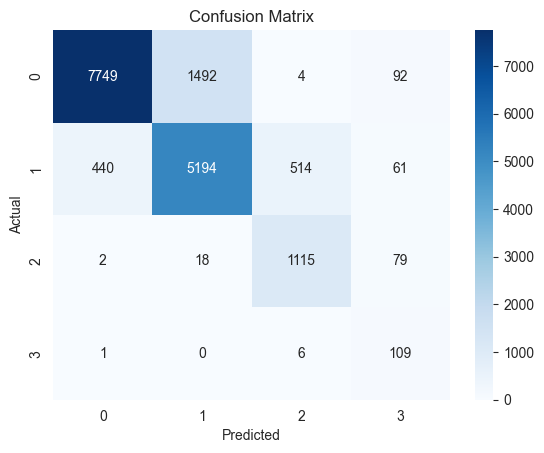

In [17]:
#Avaliação da rede para classificação
clf_trainer.evaluate(X_clf_test_t, y_clf_test_t)
y_pred_clf = clf_trainer.predict(X_clf_test_t)
print("Predicted classes:", torch.unique(y_pred_clf, return_counts=True))
print("Actual classes:", torch.unique(y_clf_test_t))

cm = confusion_matrix(y_clf_test_t.numpy(), y_pred_clf.numpy())
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [22]:
X_reg_train = analizer_reg.data_train
y_reg_train = analizer_reg.labels_train

X_reg_test = analizer_reg.data_test
y_reg_test = analizer_reg.labels_test

# Convert to tensors with proper shapes
# .values is used to get the underlying NumPy array from pandas DataFrame/Series
X_reg_train_t = torch.tensor(X_reg_train.values, dtype=torch.float32)
# Reshape labels to [num_samples, 1] for regression consistency
y_reg_train_t = torch.tensor(y_reg_train.values, dtype=torch.float32).reshape(-1, 1)

X_reg_test_t = torch.tensor(X_reg_test.values, dtype=torch.float32)
y_reg_test_t = torch.tensor(y_reg_test.values, dtype=torch.float32).reshape(-1, 1)

# --- Model Instantiation ---
# Initialize the Neural Network for regression
reg_model = BaseNeuralNetwork(input_dim=X_reg_train_t.shape[1], output_dim=1, task_type='regression')
# Initialize the trainer for the regression model
reg_trainer = NeuralNetworkTrainer(reg_model, task='regression')

# --- Train the Neural Network ---
print("\n" + "=" * 40)
print("--- Training Neural Network Regressor ---")

training_batch_size = 64
reg_trainer.train(X_reg_train_t, y_reg_train_t, epochs=100, batch_size=training_batch_size)
print("Neural Network training complete.")

# --- Evaluate the Neural Network ---
print("\n" + "=" * 40)
print("--- Evaluation on Test Set ---")

reg_model.eval() # Set the model to evaluation mode (disables dropout, BatchNorm updates)
with torch.no_grad(): # Disable gradient calculations for inference, saving memory and speeding up computations
    predictions = reg_model(X_reg_test_t)

    # Calculate Mean Squared Error (MSE)
    mse = torch.mean((predictions - y_reg_test_t) ** 2).item()
    # Calculate Mean Absolute Error (MAE)
    mae = torch.mean(torch.abs(predictions - y_reg_test_t)).item()

    # Calculate R² Score (Coefficient of Determination)
    y_mean = torch.mean(y_reg_test_t)
    ss_tot = torch.sum((y_reg_test_t - y_mean) ** 2) # Total sum of squares
    ss_res = torch.sum((y_reg_test_t - predictions) ** 2) # Residual sum of squares

    # Handle the case where ss_tot might be zero (e.g., all target values are the same in the test set)
    if ss_tot == 0:
        r2 = 1.0 if ss_res == 0 else 0.0 # If actuals are constant and predictions are perfect, R2=1. Else 0.
    else:
        r2 = 1 - (ss_res / ss_tot)

    print(f"Mean Squared Error (MSE): {mse:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.4f}")
    print(f"R² Score: {r2:.4f}")

    # Optional: Print some sample predictions vs actual values for quick inspection
    print("\nSample predictions vs actual values (first 10):")
    for i in range(min(10, len(predictions))):
        print(f"Sample {i+1}: Actual = {y_reg_test_t[i].item():.4f}, Predicted = {predictions[i].item():.4f}")

# --- Save the Neural Network Model ---
# Save only the model's state dictionary (weights and biases)
torch.save(reg_model.state_dict(), model_output_dir + "NeuralNetworkRegressor.pth")
print(f"Model state dictionary saved to {model_output_dir}/NeuralNetworkRegressor.pth")

print("\nScript execution finished.")


--- Training Neural Network Regressor ---
Starting training for 100 epochs with batch size 64...
Epoch 0 - Loss: 47.5804
Epoch 10 - Loss: 11.1952
Epoch 20 - Loss: 10.7511
Epoch 30 - Loss: 15.9020
Epoch 40 - Loss: 10.2119
Epoch 50 - Loss: 7.7366
Epoch 60 - Loss: 23.6045
Epoch 70 - Loss: 10.0366
Epoch 80 - Loss: 10.9806
Epoch 90 - Loss: 11.0602
Training finished.
Neural Network training complete.

--- Evaluation on Test Set ---
Mean Squared Error (MSE): 116109.9375
Mean Absolute Error (MAE): 19.4949
R² Score: -988.1225

Sample predictions vs actual values (first 10):
Sample 1: Actual = 9.5000, Predicted = 9.9130
Sample 2: Actual = 7.5000, Predicted = 8.3023
Sample 3: Actual = 17.5000, Predicted = 16.3368
Sample 4: Actual = 17.0000, Predicted = 16.1347
Sample 5: Actual = 8.5000, Predicted = 10.4344
Sample 6: Actual = 38.0000, Predicted = 33.2692
Sample 7: Actual = 8.5000, Predicted = 9.4682
Sample 8: Actual = 5.5000, Predicted = 6.7825
Sample 9: Actual = 7.0000, Predicted = 8.3908
Sample

# K-Prototypes (Clustering por partição)

In [ ]:
categorical_column_names_for_kproto = [
    'vendorid',
    'ratecodeid',
    'pulocationid',
    'dolocationid',
    'payment_type'
]

categorical_indices_kproto = []
if hasattr(analizer_reg, 'data_train') and isinstance(analizer_reg.data_train, pd.DataFrame):
    # Get the indices of the specified categorical column names
    for col_name in categorical_column_names_for_kproto:
        if col_name in analizer_reg.data_train.columns:
            categorical_indices_kproto.append(analizer_reg.data_train.columns.get_loc(col_name))
        else:
            print(f"Warning: Column '{col_name}' specified as categorical not found in data_train.")

    if not categorical_indices_kproto:
        print("\nCRITICAL ERROR: Categorical column indices for K-Prototypes NOT defined.")
        print("The manually specified columns were not found or are invalid.")
        print("Please ensure 'categorical_column_names_for_kproto' contains the correct names of your categorical features.")
        print("Cannot proceed with K-Prototypes without this information.")
else:
    print("Error: 'analizer_reg' or 'data_train' not found or is not a Pandas DataFrame. Please ensure 'analizer_reg' is initialized.")
    print("\nCRITICAL ERROR: Categorical column indices for K-Prototypes NOT defined.")
    print("Cannot proceed with K-Prototypes without this information.")
    categorical_indices_kproto = [] # Ensure it's empty if data is not available


if categorical_indices_kproto: # Only proceed if indices are found
    print(f"Categorical indices identified for K-Prototypes: {categorical_indices_kproto}")

    # Values for n_clusters. Can be adjusted based on data exploration.
    n_clusters_values_kproto = [3, 4, 5] # Example values for number of clusters
    best_cost_kproto = float('inf')
    best_params_kproto = None
    all_kproto_results = {} # Stores all results

    for n_cl in n_clusters_values_kproto:
        current_params = {'n_clusters': n_cl}
        print(f"\nEvaluating K-Prototypes with n_clusters = {n_cl}...")

        try:
            # Instantiate KPrototypes model
            # random_state is important for reproducibility of initialization
            kproto_model = KPrototypesModel(
                n_clusters=n_cl,
                categorical_indices=categorical_indices_kproto,
                n_init=10, # Run 10 times with different seeds and take the best result
                random_state=42
            )

            # Fit the model on the training data
            # For clustering, 'y' is ignored in the fit function
            kproto_model.fit(analizer_reg.data_train)

            # Evaluate the model (get the cost)
            # For unsupervised learning like K-Prototypes, evaluation is typically done
            # on the fitted data using internal metrics like 'cost' (distortion).
            # This is not a 'cross-validation' in the supervised learning sense.
            results_kproto = kproto_model.evaluate()
            all_kproto_results[n_cl] = results_kproto

            current_cost = results_kproto.get('cost')
            print(f"Parameters: n_clusters={n_cl}")
            if current_cost is not None:
                print(f"Cost (Distortion): {current_cost:.4f}")

                # Logic to select the best model based on the lowest cost
                if current_cost < best_cost_kproto:
                    best_cost_kproto = current_cost
                    best_params_kproto = current_params
                    print(f" -> New best parameter set for K-Prototypes found: {best_params_kproto} (Cost={best_cost_kproto:.4f})")

        except Exception as e:
            print(f"An error occurred during K-Prototypes evaluation for n_clusters {n_cl}: {e}")

    # --- Train and Save the Best K-Prototypes Clustering Model ---
    if best_params_kproto is not None:
        print("-" * 30)
        print(f"Best parameters found for K-Prototypes: {best_params_kproto}")
        print(f"Best Cost: {best_cost_kproto:.4f}")

        # 1. Re-train the final model with the best parameters on ALL training data
        # This step is already performing direct training on the full training data,
        # which is the standard practice for clustering after parameter selection.
        print(f"Re-training the K-Prototypes model with {best_params_kproto['n_clusters']} clusters on the complete training set...")
        final_best_kproto_model = KPrototypesModel(
            n_clusters=best_params_kproto['n_clusters'],
            categorical_indices=categorical_indices_kproto,
            n_init=10, # Keep the n_init used in selection
            random_state=42
        )
        final_best_kproto_model.fit(analizer_reg.data_train)

        # 2. Save the best K-Prototypes CLUSTERING model
        model_filename_kproto = f"KPrototypesClustering_nClusters.pkl"

        # Serializing the model as specified in the original request
        final_best_kproto_model.serialize(model_output_dir + model_filename_kproto)
        print(f"Best K-Prototypes model saved successfully!")
        print("-" * 30)

        # 3. Plot the clustering results
        print("\n" + "=" * 40)
        print("--- Visualizing K-Prototypes Clusters ---")
        try:
            final_best_kproto_model.plot_clusters(analizer_reg.data_train, title="K-Prototypes Clustering Results")
            print("K-Prototypes cluster visualization completed.")
        except RuntimeError as e:
            print(f"Could not plot clusters. Error: {e}")
        except Exception as e:
            print(f"An unexpected error occurred during cluster plotting: {e}")

    else:
        print("-" * 30)
        print("No K-Prototypes model was successfully evaluated and selected.")
        print("-" * 30)

print("\nScript execution finished.")

Categorical indices identified for K-Prototypes: [14, 15, 16, 17, 18]

Evaluating K-Prototypes with n_clusters = 3...


# HDBSCAN


--- Clustering with HDBSCANMixed ---

Evaluating HDBSCANMixed with min_cluster_size = 50, min_samples = None...
Iniciando o pré-processamento e treinamento HDBSCAN...


C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Treinamento concluído.
Parameters: min_cluster_size=50, min_samples=None
Number of Clusters Found: 5
Number of Noise Points: 1218 (1.47%)
Adjusted Rand Score: 0.0007
Normalized Mutual Information Score: 0.0198
 -> New best HDBSCANMixed parameters found (based on ARI): {'min_cluster_size': 50, 'min_samples': None} (ARI=0.0007)

Evaluating HDBSCANMixed with min_cluster_size = 50, min_samples = 5...
Iniciando o pré-processamento e treinamento HDBSCAN...


C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Treinamento concluído.
Parameters: min_cluster_size=50, min_samples=5
Number of Clusters Found: 19
Number of Noise Points: 6420 (7.76%)
Adjusted Rand Score: 0.0045
Normalized Mutual Information Score: 0.0617
 -> New best HDBSCANMixed parameters found (based on ARI): {'min_cluster_size': 50, 'min_samples': 5} (ARI=0.0045)

Evaluating HDBSCANMixed with min_cluster_size = 50, min_samples = 10...
Iniciando o pré-processamento e treinamento HDBSCAN...


...

C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Treinamento concluído.
Parameters: min_cluster_size=200, min_samples=5
Number of Clusters Found: 11
Number of Noise Points: 6925 (8.37%)
Adjusted Rand Score: 0.0039
Normalized Mutual Information Score: 0.0486

Evaluating HDBSCANMixed with min_cluster_size = 200, min_samples = 10...
Iniciando o pré-processamento e treinamento HDBSCAN...


C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


Treinamento concluído.
Parameters: min_cluster_size=200, min_samples=10
Number of Clusters Found: 8
Number of Noise Points: 9425 (11.40%)
Adjusted Rand Score: 0.0033
Normalized Mutual Information Score: 0.0417
------------------------------
Best parameters found for HDBSCANMixed after evaluation: {'min_cluster_size': 100, 'min_samples': 10}
Best Adjusted Rand Score: 0.0049
Saving the best HDBSCANMixed model...
Saving model in ../out/models/HDCSCAN_Clustering.pkl
Best HDBSCANMixed model saved successfully!
------------------------------

--- Visualizing HDBSCANMixed Clusters ---

--- Visualizing Numerical Features for HDBSCANMixed Clustering Results ---


C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)
C:\Users\usoda\PyCharmMiscProject\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:59: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and multiclass values for target
  warnings.warn(msg, UserWarning)


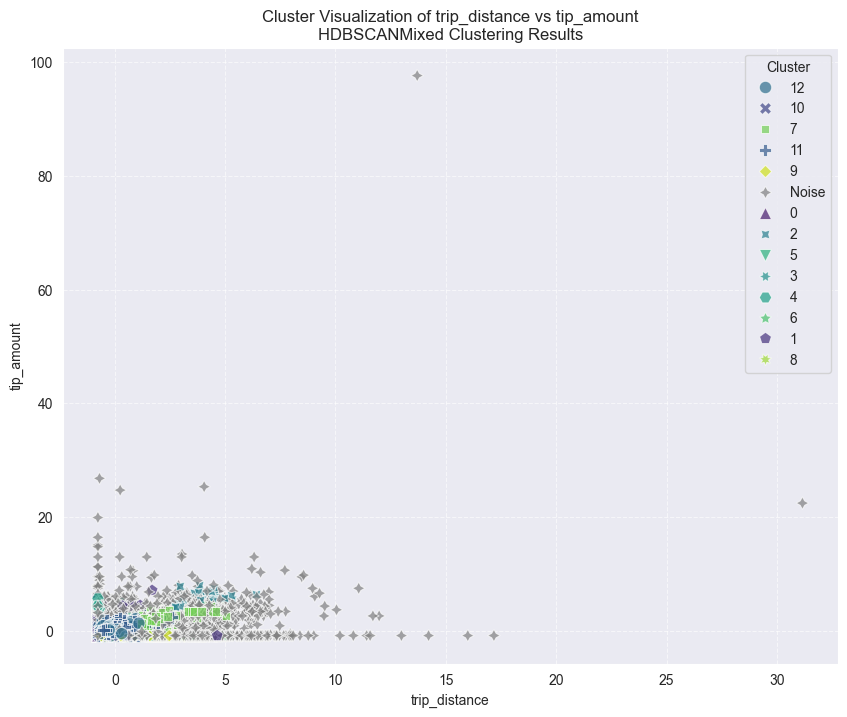

No categorical features to visualize.

--- Cluster Sizes ---
cluster_str
0          168
1          254
10        6541
11       33249
12       18536
2          150
3          241
4          110
5          109
6          181
7         1775
8          173
9        12955
Noise     8247
Name: count, dtype: int64
HDBSCANMixed cluster visualization completed.

Script execution finished.


In [4]:
print("\n" + "=" * 40)
print("--- Clustering with HDBSCANMixed ---")

# Example values for HDBSCAN hyperparameters
hdbscan_min_cluster_sizes = [50, 100, 200]
hdbscan_min_samples_values = [None, 5, 10]

best_model_hdbscan = None
best_score = -1.0 # Will store the best Adjusted Rand Score or similar (external metric)
best_hdbscan_params = None
best_noise_percentage_hdbscan = float('inf') # For heuristics without ground truth
all_hdbscan_results = {}

y_test_for_eval = getattr(analizer_reg, 'labels_train', None)


for min_cluster_s in hdbscan_min_cluster_sizes:
    for min_s_val in hdbscan_min_samples_values:
        current_params = {'min_cluster_size': min_cluster_s, 'min_samples': min_s_val}
        print(f"\nEvaluating HDBSCANMixed with min_cluster_size = {min_cluster_s}, min_samples = {min_s_val}...")

        try:
            hdbscan_model = HDBSCANMixed(
                min_cluster_size=min_cluster_s,
                min_samples=min_s_val,
                metric='euclidean', # This metric is typically for numerical data.
                                    # If 'HDBSCANMixed' truly handles mixed types,
                                    # it implies an internal mechanism or custom metric.
                prediction_data=True # Necessary for `hdbscan.HDBSCAN` to predict on new data if needed
            )

            hdbscan_model.fit(analizer_reg.data_train)

            results_hdbscan = hdbscan_model.evaluate(y_test=y_test_for_eval)
            all_hdbscan_results[(min_cluster_s, min_s_val)] = results_hdbscan

            print(f"Parameters: min_cluster_size={min_cluster_s}, min_samples={min_s_val}")

            # Calculate and print cluster statistics
            unique_labels = np.unique(hdbscan_model.labels)
            num_clusters = len(unique_labels[unique_labels != -1]) # Exclude noise points (-1)
            noise_points = np.sum(hdbscan_model.labels == -1)
            total_points = len(hdbscan_model.labels)
            noise_percentage = (noise_points / total_points) * 100 if total_points > 0 else 0

            print(f"Number of Clusters Found: {num_clusters}")
            print(f"Number of Noise Points: {noise_points} ({noise_percentage:.2f}%)")

            current_ari = results_hdbscan.get('adjusted_rand_score', -1.0)
            current_nmi = results_hdbscan.get('normalized_mutual_info_score', -1.0)

            if 'adjusted_rand_score' in results_hdbscan:
                print(f"Adjusted Rand Score: {current_ari:.4f}")
            if 'normalized_mutual_info_score' in results_hdbscan:
                print(f"Normalized Mutual Information Score: {current_nmi:.4f}")

            if y_test_for_eval is not None:
                if current_ari > best_score:
                    best_score = current_ari
                    best_hdbscan_params = current_params
                    best_model_hdbscan = hdbscan_model
                    print(f" -> New best HDBSCANMixed parameters found (based on ARI): {best_hdbscan_params} (ARI={best_score:.4f})")
            else:
                if num_clusters > 1 and noise_percentage < best_noise_percentage_hdbscan:
                    best_noise_percentage_hdbscan = noise_percentage
                    best_hdbscan_params = current_params
                    best_model_hdbscan = hdbscan_model
                    print(f" -> New best HDBSCANMixed parameters found (heuristic): {best_hdbscan_params} (Noise={best_noise_percentage_hdbscan:.2f}%, Clusters={num_clusters})")

        except Exception as e:
            print(f"An error occurred during HDBSCANMixed evaluation for parameters {current_params}: {e}")

# ========================================
# 6. SAVING AND VISUALIZING BEST MODEL
# ========================================
if best_hdbscan_params is not None:
    print("-" * 30)
    print(f"Best parameters found for HDBSCANMixed after evaluation: {best_hdbscan_params}")
    if y_test_for_eval is not None:
        print(f"Best Adjusted Rand Score: {best_score:.4f}")
    else:
        print(f"Lowest Noise Percentage (Heuristic): {best_noise_percentage_hdbscan:.2f}%")

    print(f"Saving the best HDBSCANMixed model...")

    # The serialization path is kept exactly as requested by the user.
    try:
        best_model_hdbscan.serialize(model_output_dir + "HDCSCAN_Clustering.pkl")
        print(f"Best HDBSCANMixed model saved successfully!")
    except Exception as e:
        print(f"Error saving the HDBSCANMixed model: {e}")

    print("-" * 30)

    print("\n" + "=" * 40)
    print("--- Visualizing HDBSCANMixed Clusters ---")
    try:
        # Pass the data used for fitting to the plotting function
        best_model_hdbscan.plot_clusters(analizer_reg.data_train, title="HDBSCANMixed Clustering Results")
        print("HDBSCANMixed cluster visualization completed.")
    except RuntimeError as e:
        print(f"Could not plot clusters. Error: {e}")
    except Exception as e:
        print(f"An unexpected error occurred during cluster plotting: {e}")

else:
    print("-" * 30)
    print("No HDBSCANMixed model was successfully evaluated and selected.")
    print("-" * 30)

print("\nScript execution finished.")